# 13 — Loan-Level IRB RWA and Total

## Completing loan-level IRB RWA

This notebook completes IRB by multiplying each loan's capital K by IRB EAD and 12.5, then summing the results.

IRB Credit RWA becomes the model-based credit component of aggregate RWA. The same loan-level records also retain expected loss separately.

### Expected loss and unexpected loss

| Term | Simple meaning |
|---|---|
| Expected loss | PD multiplied by LGD and EAD |
| Unexpected-loss capital | capital K multiplied by EAD |
| 12.5 conversion | the inverse of 8%, used to express capital as RWA |

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from basel_credit_risk.config import load_all_config
from basel_credit_risk.notebook_support import display, ensure_outputs

CRORE = 10_000_000
COLORS = ["#0B3A53", "#1F77B4", "#2A9D8F", "#E9C46A", "#F4A261", "#E76F51"]
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
configs = load_all_config(ROOT / "config")
ensure_outputs(ROOT)
loans = pd.read_csv(ROOT / "data/processed/current_calculated.csv.gz", low_memory=False)
print(f"Portfolio represented: {len(loans):,} synthetic exposures")

Portfolio represented: 30,000 synthetic exposures


## Representative loan-level calculations

One loan from each IRB family displays PD, final LGD, EAD, maturity, correlation, K and RWA. Every loan can therefore be recalculated from visible intermediate fields.

In [2]:
irb_examples = (
    loans.loc[loans["default_flag"].eq(0)]
    .sort_values(["irb_function", "exposure_id"])
    .groupby("irb_function", as_index=False)
    .first()[["exposure_id", "irb_function", "pd_regulatory", "lgd_regulatory", "ead_irb", "m_effective", "asset_correlation_r", "conditional_pd_999", "capital_k", "expected_loss_amount", "irb_rwa"]]
)
irb_examples[["ead_irb", "expected_loss_amount", "irb_rwa"]] /= CRORE
display(irb_examples.rename(columns={"ead_irb": "EAD (INR crore)", "expected_loss_amount": "Expected loss (INR crore)", "irb_rwa": "IRB RWA (INR crore)"}))

,exposure_id,irb_function,pd_regulatory,lgd_regulatory,EAD (INR crore),m_effective,asset_correlation_r,conditional_pd_999,capital_k,Expected loss (INR crore),IRB RWA (INR crore)
0,EXP-0009601,corporate,0.000500,0.743761,372.638892,4.670098,0.237037,0.020442,0.042117,0.138577,196.179145
1,EXP-0000001,mortgage,0.018000,0.245467,0.209763,2.006028,0.150000,0.164463,0.035952,0.000927,0.094267
2,EXP-0015601,other_retail,0.080000,0.998863,0.088284,3.052586,0.037905,0.206365,0.126221,0.007055,0.139291
3,EXP-0021601,qrre,0.007000,1.000000,0.002218,1.000000,0.040000,0.030249,0.023249,0.000016,0.000645


Expected loss and RWA are not interchangeable. Expected loss represents average credit loss. IRB RWA represents the unexpected-loss capital requirement expressed in a common RWA denominator.

## IRB Credit RWA by exposure class

EAD shows portfolio size. IRB RWA shows capital-weighted risk after the nonlinear function. The difference between the bars varies by PD, downturn LGD, correlation and maturity.

The logarithmic axis preserves the small retail classes alongside larger corporate amounts. Equal distances on this axis represent proportional changes, not equal rupee differences.

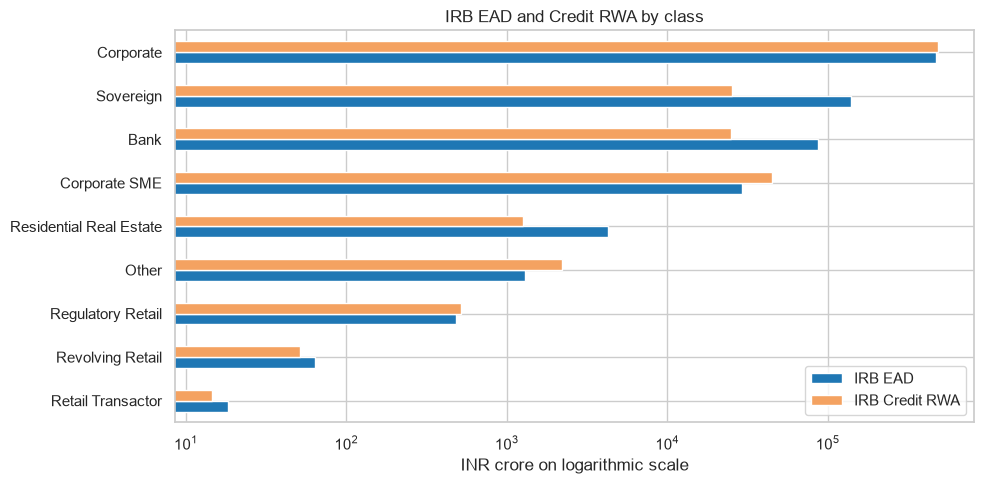

In [3]:
irb_total = loans.groupby("performing_exposure_class").agg(
    ead=("ead_irb", "sum"),
    expected_loss=("expected_loss_amount", "sum"),
    irb_rwa=("irb_rwa", "sum"),
).sort_values("ead") / CRORE
irb_plot = irb_total[["ead", "irb_rwa"]].rename(columns={"ead": "IRB EAD", "irb_rwa": "IRB Credit RWA"})
ax = irb_plot.plot.barh(figsize=(10, 5), color=[COLORS[1], COLORS[4]], title="IRB EAD and Credit RWA by class")
ax.set_yticklabels([name.replace("_", " " ).title().replace("Sme", "SME") for name in irb_plot.index])
plt.xscale("log")
plt.xlabel("INR crore on logarithmic scale")
plt.ylabel("")
plt.tight_layout()
plt.show()

A class can have lower IRB RWA than EAD without being risk free. K is a capital percentage and the 12.5 conversion determines the resulting RWA density.

## Formula and aggregation reconciliation

The first control proves `IRB RWA = 12.5 × K × EAD` for all loans. The second proves that the saved class summary equals the direct loan-level sum.

In [4]:
formula_rwa = 12.5 * loans["capital_k"] * loans["ead_irb"]
formula_difference = loans["irb_rwa"] - formula_rwa
saved_irb_summary = pd.read_csv(ROOT / "outputs/tables/irb_summary.csv")
aggregation_difference = loans["irb_rwa"].sum() - saved_irb_summary["irb_rwa"].sum()

display(pd.DataFrame({
    "Control": ["Loan formula", "Loan sum to class summary"],
    "Difference (INR crore)": [formula_difference.abs().max() / CRORE, aggregation_difference / CRORE],
    "Status": ["PASS" if formula_difference.abs().max() < 0.01 else "FAIL", "PASS" if abs(aggregation_difference) < 0.01 else "FAIL"],
}))
assert formula_difference.abs().max() < 0.01
assert abs(aggregation_difference) < 0.01

,Control,Difference (INR crore),Status
0,Loan formula,0.000000,PASS
1,Loan sum to class summary,0.000000,PASS


Both PASS results reconcile IRB at loan and portfolio level. Notebook 14 identifies market and operational RWA before the comparison in notebook 15.